In [9]:
import numpy as np

class NeuralNetwork:
    def __init__(
        self,
        network_input_size,
        layer_output_sizes,
        activation_funcs,
        activation_ders,
        cost_fun,
        cost_der,
        lr=1e-2,
        seed=0,
    ):
        self.input_size = int(network_input_size)
        self.sizes = list(map(int, layer_output_sizes))   # <-- make consistent
        self.activation_funcs = activation_funcs
        self.activation_ders = activation_ders
        self.cost_fun = cost_fun
        self.cost_der = cost_der
        self.lr = float(lr)

        rng = np.random.default_rng(seed)

        layers = []
        in_size = self.input_size
        for out_size, _ in zip(self.sizes, self.activation_funcs):
            W = rng.normal(0.0, 0.01, size=(in_size, out_size))  # simple small normal init
            b = np.zeros((1, out_size))
            layers.append([W, b])
            in_size = out_size
        self.layers = layers

    def predict(self, inputs):
        a = inputs
        for (W, b), act in zip(self.layers, self.activation_funcs):
            z = a @ W + b
            a = act(z)
        return a

    def cost(self, inputs, targets):
        yhat = self.predict(inputs)
        return self.cost_fun(yhat, targets)

    def _feed_forward_saver(self, inputs):
        activations = [inputs]
        zs = []
        a = inputs
        for (W, b), act in zip(self.layers, self.activation_funcs):
            z = a @ W + b
            a = act(z)
            zs.append(z)
            activations.append(a)
        return activations, zs

    def compute_gradient(self, inputs, targets):
        m = inputs.shape[0]
        As, Zs = self._feed_forward_saver(inputs)
        yhat = As[-1]

        grads = [None] * len(self.layers)

        # For softmax + cross-entropy use identity derivative on last layer
        delta = self.cost_der(yhat, targets) * self.activation_ders[-1](Zs[-1])

        dW = (As[-2].T @ delta) / m
        db = np.sum(delta, axis=0, keepdims=True) / m
        grads[-1] = (dW, db)

        for L in range(len(self.layers) - 2, -1, -1):
            W_next = self.layers[L + 1][0]
            delta = (delta @ W_next.T) * self.activation_ders[L](Zs[L])
            dW = (As[L].T @ delta) / m
            db = np.sum(delta, axis=0, keepdims=True) / m
            grads[L] = (dW, db)

        return grads

    def update_weights(self, layer_grads):
        for (W, b), (dW, db) in zip(self.layers, layer_grads):
            W -= self.lr * dW
            b -= self.lr * db



In [10]:
def relu(z): return np.maximum(0, z)
def drelu(z): return (z > 0).astype(z.dtype)

def sigmoid(z): return 1.0 / (1.0 + np.exp(-z))
def dsigmoid(z):
    s = sigmoid(z)
    return s * (1.0 - s)

def softmax(z):
    z_stable = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z_stable)
    return exp_z / (np.sum(exp_z, axis=1, keepdims=True) + 1e-12)

def xent(yhat_softmax, y_oneshot):
    eps = 1e-12
    yhat = np.clip(yhat_softmax, eps, 1.0 - eps)
    return -np.mean(np.sum(y_oneshot * np.log(yhat), axis=1))

def dxent_softmax(yhat_softmax, y_oneshot):
    # gradient w.r.t. softmax output (combine with identity derivative on logits)
    return (yhat_softmax - y_oneshot)

def identity_derivative(z):  # for last layer with softmax+xent trick
    return np.ones_like(z)

In [15]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
seed = 6114


iris = datasets.load_iris()
X = iris.data.astype(float)
y = iris.target

# one-hot encoding
Y = np.zeros((len(y), 3))
Y[np.arange(len(y)), y] = 1.0

# standardize features
X = (X - X.mean(axis=0, keepdims=True)) / (X.std(axis=0, keepdims=True) + 1e-14)

X_train, X_test, Y_train, Y_test, y_train, y_test = train_test_split(
    X, Y, y, test_size=0.2, random_state=seed, stratify=y
)

nn = NeuralNetwork(
    network_input_size=4,
    layer_output_sizes=[16, 3],                      # [hidden, output]
    activation_funcs=[relu, softmax],                # last = softmax
    activation_ders=[drelu, identity_derivative],    # last derivative = identity
    cost_fun=xent,
    cost_der=dxent_softmax,
    lr=0.05,
    seed=123,
)

epochs = 800
for ep in range(1, epochs + 1):
    grads = nn.compute_gradient(X_train, Y_train)
    nn.update_weights(grads)
    if ep % 100 == 0 or ep == 1:
        yhat_tr = nn.predict(X_train)
        loss_tr = xent(yhat_tr, Y_train)
        preds_tr = np.argmax(yhat_tr, axis=1)
        acc_tr = np.mean(preds_tr == y_train)
        print(f"epoch {ep:4d} | train loss={loss_tr:.4f} | train acc={acc_tr:.3f}")

yhat_test = nn.predict(X_test)
test_loss = xent(yhat_test, Y_test)
y_pred = np.argmax(yhat_test, axis=1)
test_acc = np.mean(y_pred == y_test)
print(f"\nTest loss: {test_loss:.4f} | Test accuracy: {test_acc:.3f}")

epoch    1 | train loss=1.0985 | train acc=0.517
epoch  100 | train loss=0.9761 | train acc=0.683
epoch  200 | train loss=0.4566 | train acc=0.817
epoch  300 | train loss=0.3190 | train acc=0.900
epoch  400 | train loss=0.2458 | train acc=0.925
epoch  500 | train loss=0.1955 | train acc=0.958
epoch  600 | train loss=0.1577 | train acc=0.967
epoch  700 | train loss=0.1296 | train acc=0.967
epoch  800 | train loss=0.1095 | train acc=0.975

Test loss: 0.1425 | Test accuracy: 0.967


In [17]:
def accuracy_from_probs(probs, y_true_int):
    preds = np.argmax(probs, axis=1)
    return np.mean(preds == y_true_int)


In [28]:
hidden_layers_list = [0, 1, 2, 3]
hidden_nodes_list  = [5, 10, 25, 50]
epochs = 10000
lr = 0.005
seed = 6114
K = 3

results = np.zeros((len(hidden_layers_list), len(hidden_nodes_list)), dtype=float)


for i, L in enumerate(hidden_layers_list):
    for j, H in enumerate(hidden_nodes_list):
        layer_sizes = ([H] * L) + [K]
        acts = ([relu] * L) + [softmax]
        ders = ([drelu] * L) + [identity_derivative]

        nn = NeuralNetwork(
            network_input_size=X_train.shape[1],
            layer_output_sizes=layer_sizes,
            activation_funcs=acts,
            activation_ders=ders,
            cost_fun=xent,
            cost_der=dxent_softmax,
            lr=lr,
        )

        for ep in range(epochs):
            grads = nn.compute_gradient(X_train, Y_train)
            nn.update_weights(grads)

        probs_test = nn.predict(X_test)
        acc = accuracy_from_probs(probs_test, y_test)
        results[i, j] = acc
        print(f"Hidden layers={L}, nodes={H:2d} -> test acc={acc:.3f}")


Hidden layers=0, nodes= 5 -> test acc=0.967
Hidden layers=0, nodes=10 -> test acc=0.967
Hidden layers=0, nodes=25 -> test acc=0.967
Hidden layers=0, nodes=50 -> test acc=0.967
Hidden layers=1, nodes= 5 -> test acc=0.967
Hidden layers=1, nodes=10 -> test acc=0.967
Hidden layers=1, nodes=25 -> test acc=0.967
Hidden layers=1, nodes=50 -> test acc=0.967
Hidden layers=2, nodes= 5 -> test acc=0.667
Hidden layers=2, nodes=10 -> test acc=0.800
Hidden layers=2, nodes=25 -> test acc=0.667
Hidden layers=2, nodes=50 -> test acc=0.867
Hidden layers=3, nodes= 5 -> test acc=0.667
Hidden layers=3, nodes=10 -> test acc=0.533
Hidden layers=3, nodes=25 -> test acc=0.833
Hidden layers=3, nodes=50 -> test acc=0.767


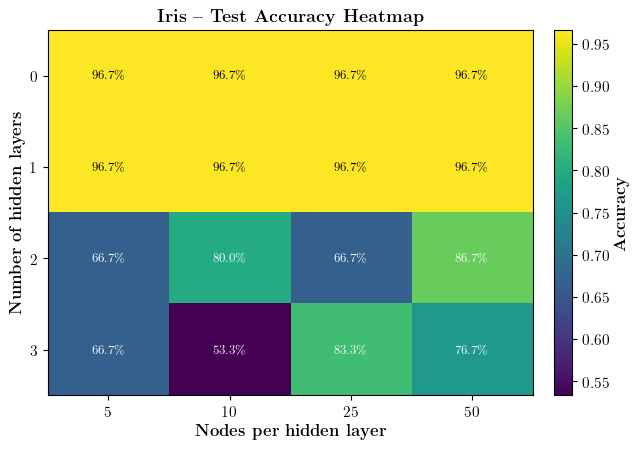

In [32]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# Enable LaTeX-style text rendering
mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})

fig, ax = plt.subplots(figsize=(6.5, 4.6))
im = ax.imshow(results, origin='upper', aspect='auto')

ax.set_xticks(np.arange(len(hidden_nodes_list)), labels=[str(h) for h in hidden_nodes_list])
ax.set_yticks(np.arange(len(hidden_layers_list)), labels=[str(l) for l in hidden_layers_list])
ax.set_xlabel(r"\textbf{Nodes per hidden layer}")
ax.set_ylabel(r"\textbf{Number of hidden layers}")
ax.set_title(r"\textbf{Iris -- Test Accuracy Heatmap}")

for i in range(results.shape[0]):
    for j in range(results.shape[1]):
        ax.text(j, i, f"{results[i,j]*100:.1f}\\%", ha="center", va="center",
                fontsize=9, color="black" if results[i,j] > 0.9 else "white")

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label(r"\textbf{Accuracy}")

plt.tight_layout()
plt.savefig("iris_nn_heatmap.pdf", bbox_inches="tight")
plt.show()


Test accuracy of a fully connected neural network trained on the Iris dataset for different network architectures. The heatmap shows the test accuracy for models with 0--3 hidden layers and 5--50 nodes per hidden layer. A model with no hidden layers achieves the highest accuracy, demonstrating that the Iris dataset is nearly linearly separable. Deeper networks perform worse due to overfitting and unstable convergence on this small dataset.


The heatmap shows that models with zero or one hidden layer achieve the highest test accuracy, around 96–97%, while deeper networks with two or three hidden layers perform worse. This outcome is expected for the Iris dataset, which is almost linearly separable after normalization. A model without hidden layers effectively performs multinomial logistic regression, which is already sufficient to separate the three flower classes. Adding more layers introduces additional parameters and nonlinearity but provides little benefit for a problem that does not require complex decision boundaries.

The reduced performance for deeper networks can also be explained by the small dataset size and the simple gradient descent training setup. With limited data, deeper models are more prone to overfitting or unstable convergence, especially when using small random initial weights and the same learning rate across all configurations. As a result, shallow networks generalize better on this task, while deeper architectures struggle to optimize effectively and yield lower accuracy.

epoch    1 | train loss=1.0985 | train acc=0.517
epoch  100 | train loss=0.9761 | train acc=0.683
epoch  200 | train loss=0.4566 | train acc=0.817
epoch  300 | train loss=0.3190 | train acc=0.900
epoch  400 | train loss=0.2458 | train acc=0.925
epoch  500 | train loss=0.1955 | train acc=0.958
epoch  600 | train loss=0.1577 | train acc=0.967
epoch  700 | train loss=0.1296 | train acc=0.967
epoch  800 | train loss=0.1095 | train acc=0.975

Test loss: 0.1425 | Test accuracy: 0.967


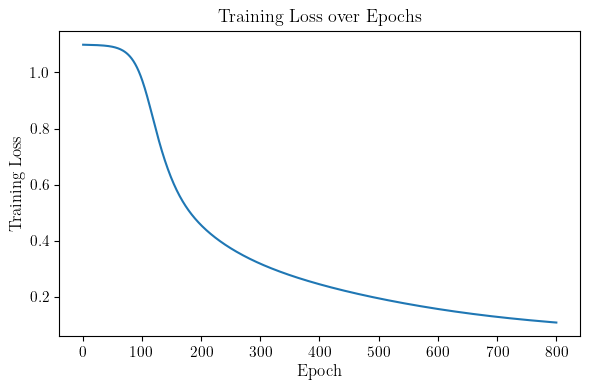

In [ ]:
nn = NeuralNetwork(
    network_input_size=4,
    layer_output_sizes=[16, 3],                      
    activation_funcs=[relu, softmax],                
    activation_ders=[drelu, identity_derivative],    
    cost_fun=xent,
    cost_der=dxent_softmax,
    lr=0.05,
    seed=123,
)

epochs = 800
train_losses = []

for ep in range(1, epochs + 1):
    grads = nn.compute_gradient(X_train, Y_train)
    nn.update_weights(grads)

    # Compute loss every epoch
    yhat_tr = nn.predict(X_train)
    loss_tr = xent(yhat_tr, Y_train)
    train_losses.append(loss_tr)

    # Optionally monitor progress
    if ep % 100 == 0 or ep == 1:
        preds_tr = np.argmax(yhat_tr, axis=1)
        acc_tr = np.mean(preds_tr == y_train)
        print(f"epoch {ep:4d} | train loss={loss_tr:.4f} | train acc={acc_tr:.3f}")

# Evaluate test set
yhat_test = nn.predict(X_test)
test_loss = xent(yhat_test, Y_test)
y_pred = np.argmax(yhat_test, axis=1)
test_acc = np.mean(y_pred == y_test)
print(f"\nTest loss: {test_loss:.4f} | Test accuracy: {test_acc:.3f}")

# --- Plot training loss over epochs ---
plt.figure(figsize=(6,4))
plt.plot(range(1, epochs + 1), train_losses, color="tab:blue")
plt.title("Training Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.tight_layout()
plt.savefig("training_loss_over_epochs.pdf", bbox_inches="tight")
plt.show()


Training loss as a function of epochs for a fully connected neural network trained on the Iris dataset. The model consists of one hidden layer with 16 nodes and uses the ReLU activation function in the hidden layer and a softmax output layer. The loss decreases steadily over 800 epochs, indicating convergence of the model through gradient-based optimization.}
